# DINO Attention 시각화

DINO 모델이 이미지의 **어디를 보는지** 시각화

CLS token의 Self-Attention heatmap을 통해 어떤 패치가 중요한지 확인

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
import numpy as np

import vision_transformer as vits

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device = {device}")

device = cuda


## 설정

Inference 설정: 모델 종류, 패치 크기, 이미지 경로 등

In [ ]:
# 수정할 곳
image_path = None  # 이미지 경로 (None이면 샘플 이미지 다운로드)
arch = "vit_small"  # 모델: vit_tiny, vit_small, vit_base
patch_size = 8  # 패치 크기: 8 또는 16

## 모델 로드

사전학습된 DINO 모델을 다운로드

In [3]:
model = vits.__dict__[arch](patch_size=patch_size, num_classes=0)
model.eval()
model.to(device)

# 사전학습 가중치 URL
url_map = {
    ("vit_small", 16): "dino_deitsmall16_pretrain/dino_deitsmall16_pretrain.pth",
    ("vit_small", 8): "dino_deitsmall8_300ep_pretrain/dino_deitsmall8_300ep_pretrain.pth",
    ("vit_base", 16): "dino_vitbase16_pretrain/dino_vitbase16_pretrain.pth",
    ("vit_base", 8): "dino_vitbase8_pretrain/dino_vitbase8_pretrain.pth",
}
url = url_map.get((arch, patch_size))
if url:
    state_dict = torch.hub.load_state_dict_from_url("https://dl.fbaipublicfiles.com/dino/" + url)
    model.load_state_dict(state_dict, strict=True)
    print(f"모델 로드 완료: {arch}, patch_size={patch_size}")
else:
    print("해당 조합의 사전학습 가중치가 없습니다. 랜덤 가중치 사용.")

Downloading: "https://dl.fbaipublicfiles.com/dino/dino_deitsmall8_300ep_pretrain/dino_deitsmall8_300ep_pretrain.pth" to /home/user/.cache/torch/hub/checkpoints/dino_deitsmall8_300ep_pretrain.pth
100%|██████████| 82.7M/82.7M [00:01<00:00, 58.5MB/s]


모델 로드 완료: vit_small, patch_size=8


## 이미지 로드

샘플 이미지 다운로드 중...


/home/user/anaconda3/envs/tts-gpu/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/user/anaconda3/envs/tts-gpu/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/user/anaconda3/envs/tts-gpu/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/user/anaconda3/envs/tts-gpu/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/user/anaconda3/envs/tts-gpu/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 

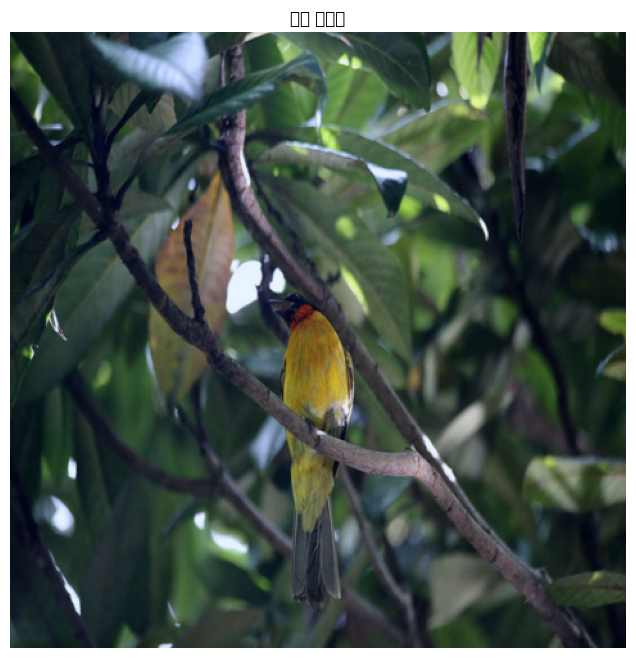

이미지 크기: (480, 480)


In [4]:
if image_path is None:
    # 샘플 이미지 다운로드
    import requests
    from io import BytesIO
    print("샘플 이미지 다운로드 중...")
    response = requests.get("https://dl.fbaipublicfiles.com/dino/img.png")
    img = Image.open(BytesIO(response.content)).convert('RGB')
else:
    img = Image.open(image_path).convert('RGB')

# 원본 이미지 보기
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.title("원본 이미지")
plt.axis('off')
plt.show()

print(f"이미지 크기: {img.size}")

## 이미지 전처리

모델에 넣기 위해 이미지를 텐서로 변환하고 정규화

In [5]:
transform = transforms.Compose([
    transforms.Resize((480, 480)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

img_tensor = transform(img)

# 패치 크기로 나눠 떨어지게 조정
w = img_tensor.shape[1] - img_tensor.shape[1] % patch_size
h = img_tensor.shape[2] - img_tensor.shape[2] % patch_size
img_tensor = img_tensor[:, :w, :h].unsqueeze(0)  # 배치 차원 추가

print(f"텐서 shape: {list(img_tensor.shape)}")
print(f"패치 그리드: {w // patch_size} x {h // patch_size}")

텐서 shape: [1, 3, 480, 480]
패치 그리드: 60 x 60


## Attention 추출

모델의 마지막 레이어에서 Self-Attention을 추출

CLS 토큰이 각 패치에 얼마나 주목하는지를 확인

In [6]:
w_featmap = img_tensor.shape[-2] // patch_size
h_featmap = img_tensor.shape[-1] // patch_size

with torch.no_grad():
    attentions = model.get_last_selfattention(img_tensor.to(device))

nh = attentions.shape[1]  # attention head 개수
print(f"Attention heads: {nh}개")

# CLS 토큰 -> 각 패치 attention만 추출
attentions = attentions[0, :, 0, 1:].reshape(nh, -1)
attentions = attentions.reshape(nh, w_featmap, h_featmap)

# 원본 이미지 크기로 업샘플링
attentions = nn.functional.interpolate(
    attentions.unsqueeze(0), 
    scale_factor=patch_size, 
    mode="nearest"
)[0].cpu().numpy()

print(f"Attention map shape: {attentions.shape}")

Attention heads: 6개
Attention map shape: (6, 480, 480)


## Attention 히트맵 시각화

각 Attention Head의 높은 attention score 영역을 표시

/tmp/ipykernel_13567/4143874544.py:17: UserWarning: Glyph 55176 (\N{HANGUL SYLLABLE HI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13567/4143874544.py:17: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13567/4143874544.py:17: UserWarning: Glyph 47605 (\N{HANGUL SYLLABLE MAEB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/user/anaconda3/envs/tts-gpu/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 55176 (\N{HANGUL SYLLABLE HI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/user/anaconda3/envs/tts-gpu/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/user/anaconda3/envs/tts-gpu/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47605 (\

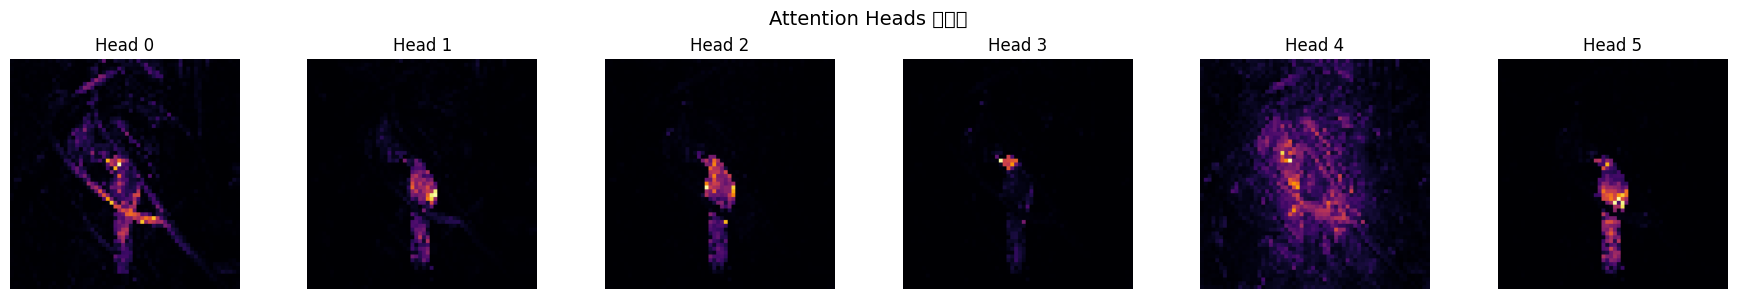

In [7]:
cols = min(6, nh)
rows = (nh + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = axes.flatten() if nh > 1 else [axes]

for i in range(nh):
    axes[i].imshow(attentions[i], cmap='inferno')
    axes[i].set_title(f"Head {i}")
    axes[i].axis('off')

# 빈 subplot 숨기기
for i in range(nh, len(axes)):
    axes[i].axis('off')

plt.suptitle("Attention Heads 히트맵", fontsize=14)
plt.tight_layout()
plt.show()

## Threshold 마스크

Attention 값이 높은 영역만 마스크로 표시

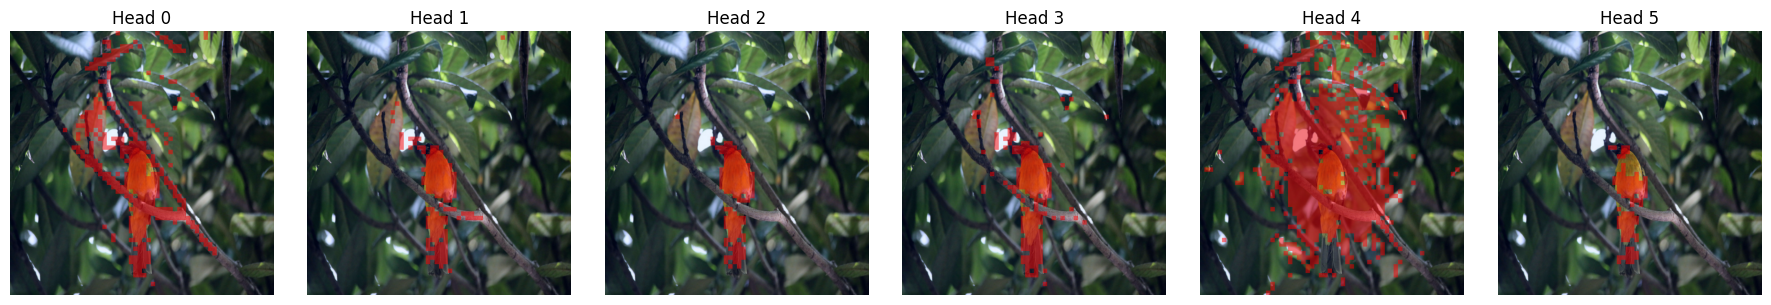

In [ ]:
threshold = 0.6
if threshold is not None:
    # 원본 이미지 리사이즈
    img_resized = img.resize((attentions.shape[2], attentions.shape[1]))
    img_np = np.array(img_resized)
    
    cols = min(6, nh)
    rows = (nh + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
    axes = axes.flatten() if nh > 1 else [axes]
    
    for i in range(nh):
        attn = attentions[i]
        
        # threshold 적용: 상위 (1-threshold) 영역만 남김
        sorted_attn = np.sort(attn.flatten())
        cumsum = np.cumsum(sorted_attn) / sorted_attn.sum()
        th_val = sorted_attn[np.searchsorted(cumsum, 1-threshold)] # threshold = 0.6
        mask = (attn >= th_val).astype(float)
        
        # 마스크 오버레이
        overlay = img_np.copy().astype(float)
        for c in range(3):
            overlay[:, :, c] = overlay[:, :, c] * (1 - 0.5 * mask) + 0.5 * mask * 255 * (c == 0)
        
        axes[i].imshow(overlay.astype(np.uint8))
        axes[i].set_title(f"Head {i}")
        axes[i].axis('off')
    
    for i in range(nh, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("threshold=None 이므로 마스크 시각화 스킵")

## 평균 Attention

모든 Head의 Attention을 평균내서 전체적으로 어디에 집중하는지 확인

/tmp/ipykernel_13567/243258344.py:22: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13567/243258344.py:22: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13567/243258344.py:22: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13567/243258344.py:22: UserWarning: Glyph 48120 (\N{HANGUL SYLLABLE MI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13567/243258344.py:22: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13567/243258344.py:22: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_13567/243258344.py:22: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_

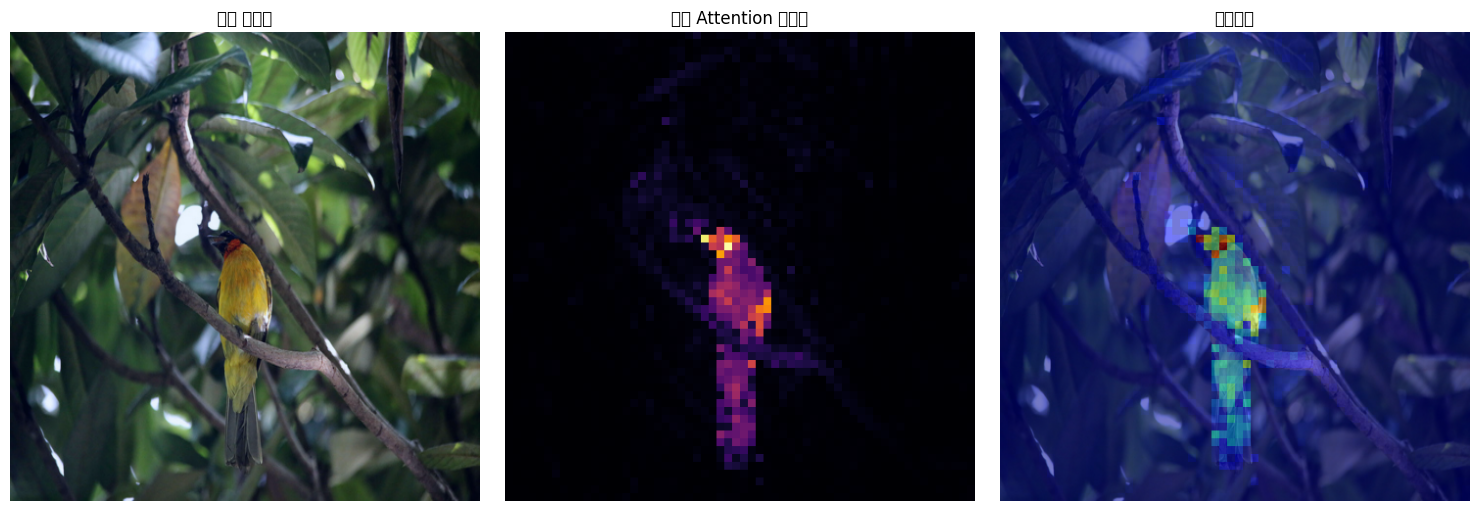

완료!


In [9]:
mean_attn = attentions.mean(axis=0)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 원본
img_resized = img.resize((mean_attn.shape[1], mean_attn.shape[0]))
axes[0].imshow(img_resized)
axes[0].set_title("원본 이미지")
axes[0].axis('off')

# 히트맵
axes[1].imshow(mean_attn, cmap='inferno')
axes[1].set_title("평균 Attention 히트맵")
axes[1].axis('off')

# 오버레이
axes[2].imshow(img_resized)
axes[2].imshow(mean_attn, cmap='jet', alpha=0.5)
axes[2].set_title("오버레이")
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("완료!")